# Seaborn — Statistical Data Visualisation

Seaborn is built on Matplotlib and makes statistical plots beautiful by default. It integrates tightly with Pandas DataFrames.

Topics:
- Distribution plots: histplot, kdeplot, ecdfplot
- Categorical plots: boxplot, violinplot, barplot, countplot, stripplot
- Relationship plots: scatterplot, lineplot, regplot
- Matrix plots: heatmap, clustermap
- Pair plots
- Themes and palettes

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print('Seaborn version:', sns.__version__)

# Load built-in datasets — no downloads needed
tips    = sns.load_dataset('tips')      # restaurant bills
titanic = sns.load_dataset('titanic')   # titanic passengers
iris    = sns.load_dataset('iris')      # iris flower measurements

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print(tips.head())
print(tips.shape)

Seaborn version: 0.13.2
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
(244, 7)


## 0b. Conceptual Foundation — Seaborn as a Statistical Layer on Matplotlib

Every Seaborn plotting function does its statistical work first — binning, KDE estimation,
aggregation with a confidence interval, regression fitting — and then draws the result through
Matplotlib's Figure/Axes API underneath. Almost every Seaborn function **returns the Matplotlib
`Axes` object it drew onto** (or a `FacetGrid`/`PairGrid` wrapping one or more Axes) — which is
exactly why `ax=axes[0]` works as an argument throughout this notebook, and why any Seaborn
result can be further customised with plain Matplotlib calls (`ax.set_title(...)`,
`ax.axhline(...)`, …). The two libraries share one object model — see `../05-matplotlib/` for
the Figure/Axes hierarchy Seaborn is built on.

sns.boxplot returns: <class 'matplotlib.axes._axes.Axes'>
Same object as the ax passed in: True


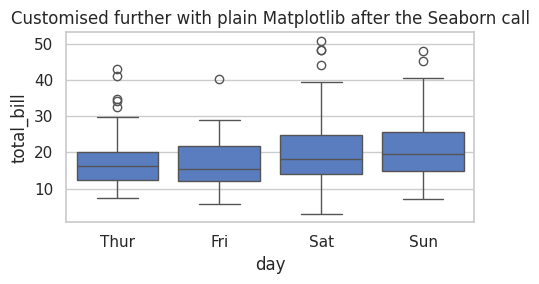

In [2]:
fig, ax = plt.subplots(figsize=(5, 3))
returned = sns.boxplot(data=tips, x='day', y='total_bill', ax=ax)
print('sns.boxplot returns:', type(returned))
print('Same object as the ax passed in:', returned is ax)
ax.set_title('Customised further with plain Matplotlib after the Seaborn call')
plt.tight_layout()
plt.show()

## 1. Distribution Plots

Visualize the distribution of a single numeric variable.

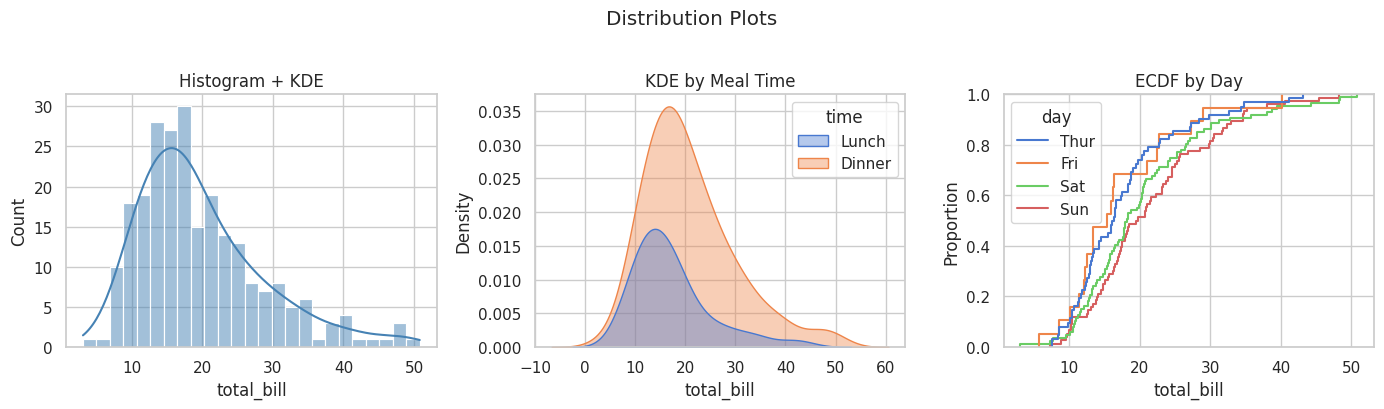

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# histplot — histogram with optional KDE overlay
sns.histplot(tips['total_bill'], bins=25, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Histogram + KDE')

# kdeplot — smooth density estimate
sns.kdeplot(data=tips, x='total_bill', hue='time', fill=True, alpha=0.4, ax=axes[1])
axes[1].set_title('KDE by Meal Time')

# ecdfplot — empirical cumulative distribution
sns.ecdfplot(data=tips, x='total_bill', hue='day', ax=axes[2])
axes[2].set_title('ECDF by Day')

plt.suptitle('Distribution Plots', y=1.02)
plt.tight_layout()
plt.show()

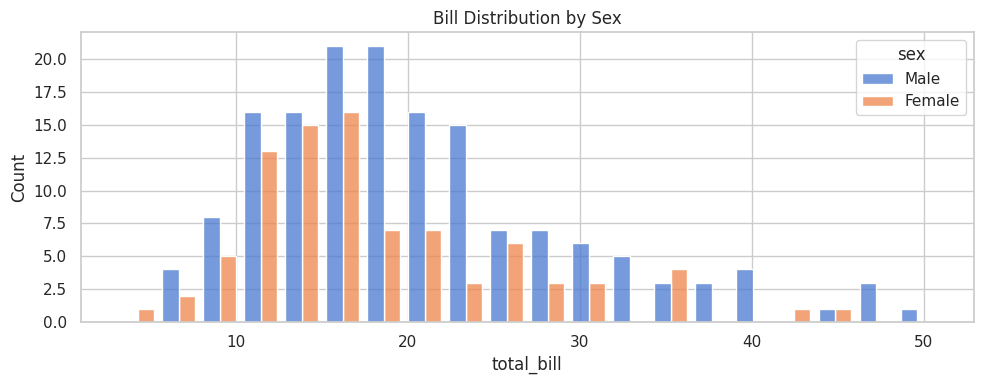

In [4]:
# Compare distributions across a categorical variable
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(data=tips, x='total_bill', hue='sex', bins=20,
             multiple='dodge', shrink=0.8, ax=ax)
ax.set_title('Bill Distribution by Sex')
plt.tight_layout()
plt.show()

## 2. Categorical Plots

Compare numeric values across categories.

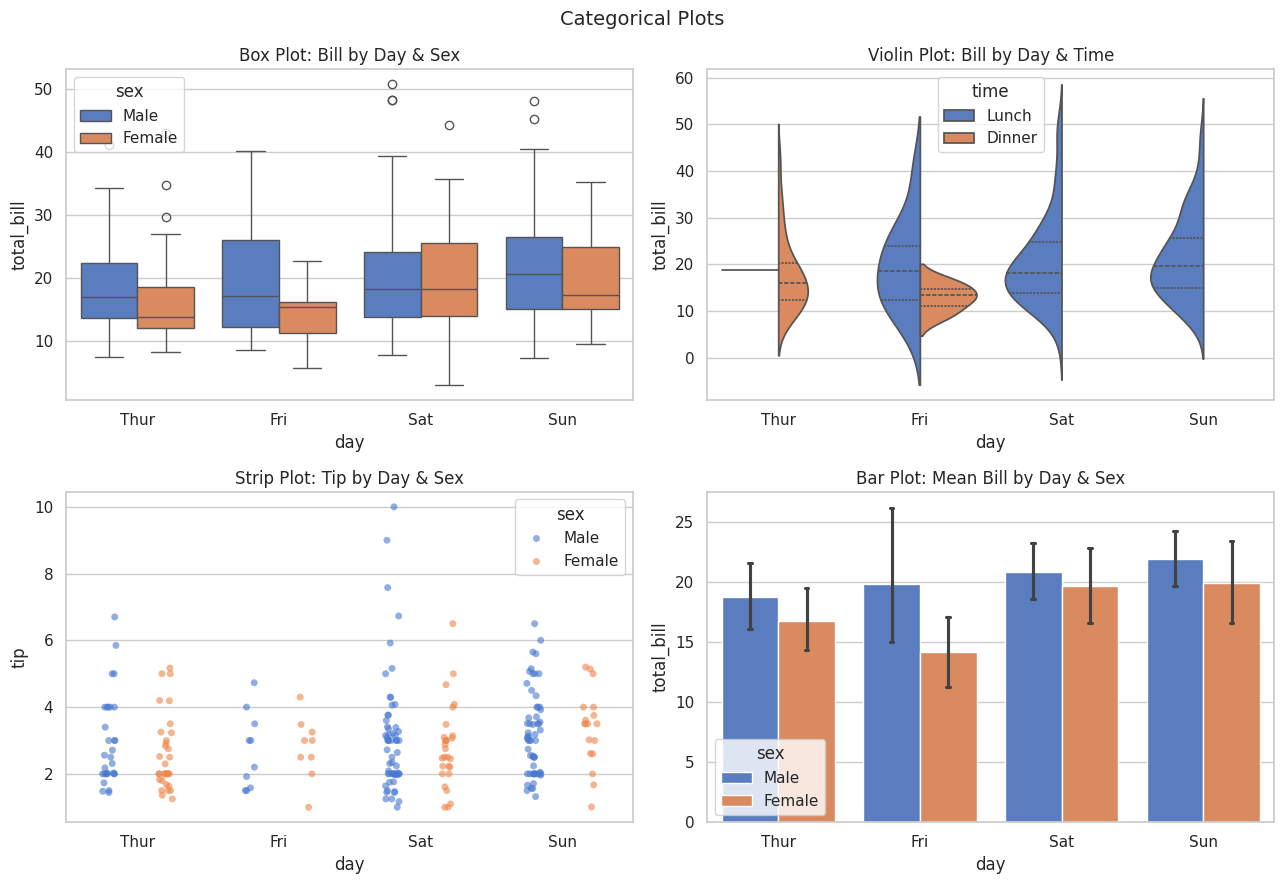

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# boxplot — shows quartiles and outliers
sns.boxplot(data=tips, x='day', y='total_bill', hue='sex', ax=axes[0,0])
axes[0,0].set_title('Box Plot: Bill by Day & Sex')

# violinplot — combines boxplot with KDE
sns.violinplot(data=tips, x='day', y='total_bill', hue='time',
               split=True, inner='quartile', ax=axes[0,1])
axes[0,1].set_title('Violin Plot: Bill by Day & Time')

# stripplot — individual points (good with small data)
sns.stripplot(data=tips, x='day', y='tip', hue='sex',
              jitter=True, dodge=True, alpha=0.6, ax=axes[1,0])
axes[1,0].set_title('Strip Plot: Tip by Day & Sex')

# barplot — mean + CI
sns.barplot(data=tips, x='day', y='total_bill', hue='sex',
            errorbar='ci', capsize=0.05, ax=axes[1,1])
axes[1,1].set_title('Bar Plot: Mean Bill by Day & Sex')

plt.suptitle('Categorical Plots', fontsize=14)
plt.tight_layout()
plt.show()

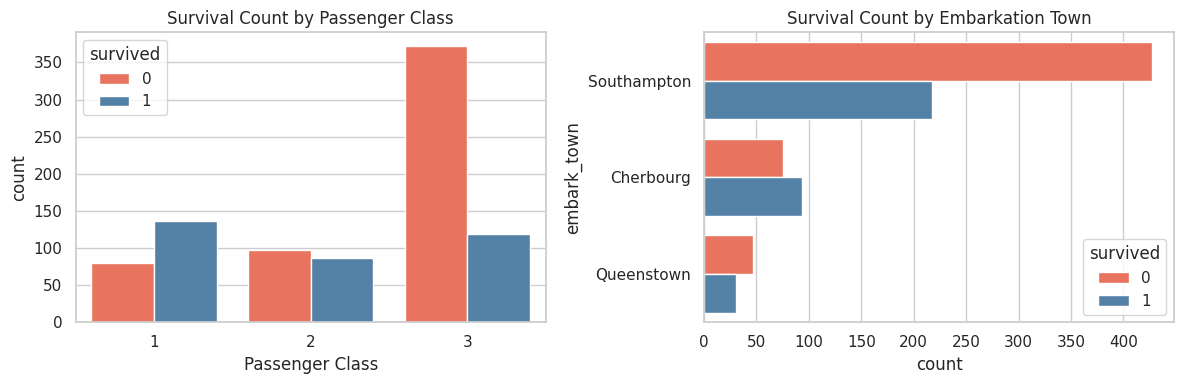

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# countplot — count of observations per category
sns.countplot(data=titanic, x='pclass', hue='survived', 
              palette=['tomato','steelblue'], ax=axes[0])
axes[0].set_title('Survival Count by Passenger Class')
axes[0].set_xlabel('Passenger Class')

# Horizontal countplot
sns.countplot(data=titanic, y='embark_town', hue='survived',
              palette=['tomato','steelblue'], ax=axes[1])
axes[1].set_title('Survival Count by Embarkation Town')

plt.tight_layout()
plt.show()

## 3. Relationship Plots

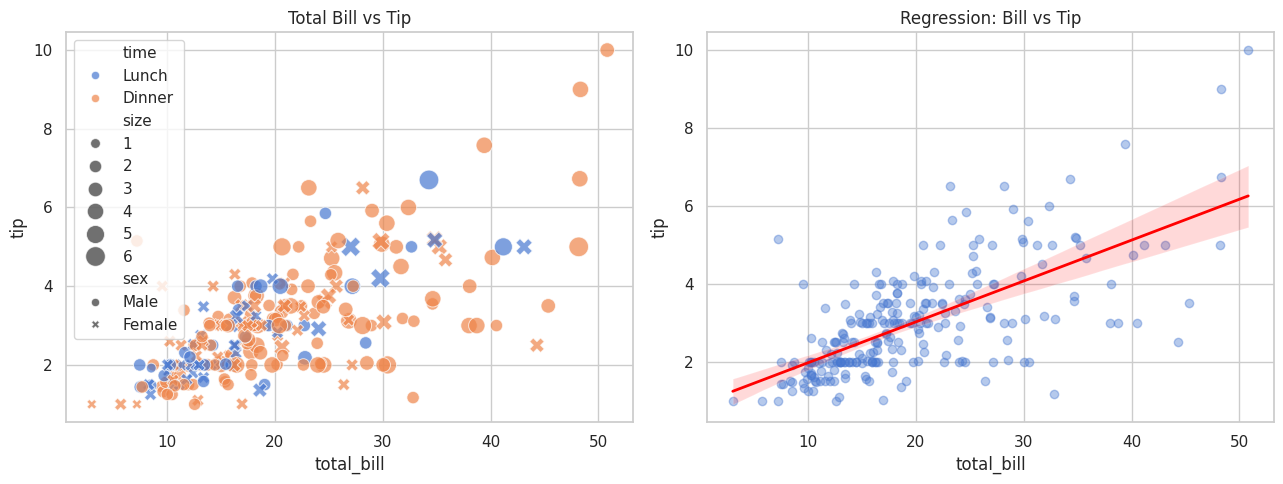

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# scatterplot with hue, size, style
sns.scatterplot(data=tips, x='total_bill', y='tip',
                hue='time', size='size', style='sex',
                sizes=(50, 200), alpha=0.7, ax=axes[0])
axes[0].set_title('Total Bill vs Tip')

# regplot — scatter + linear regression line
sns.regplot(data=tips, x='total_bill', y='tip',
            scatter_kws={'alpha':0.4}, line_kws={'color':'red','linewidth':2}, ax=axes[1])
axes[1].set_title('Regression: Bill vs Tip')

plt.tight_layout()
plt.show()

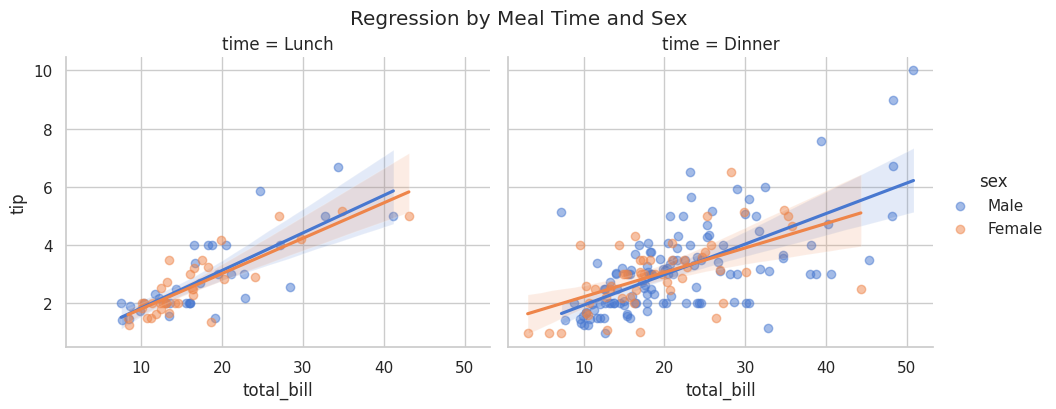

In [8]:
# lmplot — faceted regression (one per hue level)
g = sns.lmplot(data=tips, x='total_bill', y='tip',
               col='time', hue='sex',
               scatter_kws={'alpha':0.5}, height=4, aspect=1.2)
g.figure.suptitle('Regression by Meal Time and Sex', y=1.02)
plt.show()

## 4. Heatmap — Correlation Matrix

The most important visualisation for understanding feature relationships before building ML models.

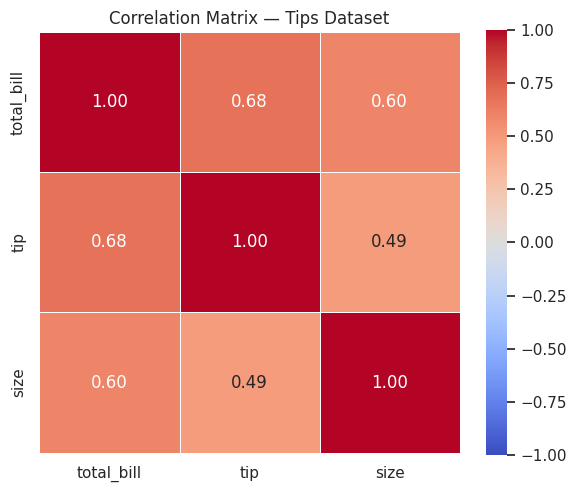

In [9]:
# Correlation matrix
numeric_cols = tips.select_dtypes(include='number')
corr = numeric_cols.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Tips Dataset')
plt.tight_layout()
plt.show()

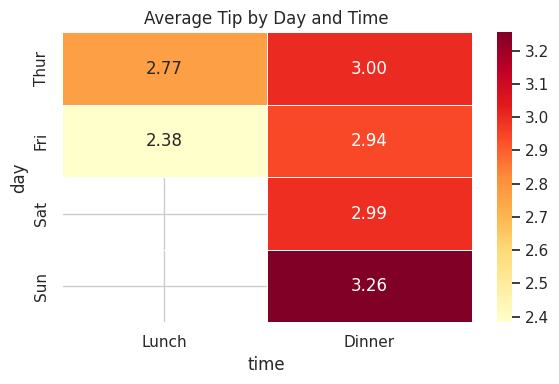

In [10]:
# Pivot heatmap — frequency table visualised
pivot = tips.pivot_table(values='tip', index='day', columns='time', aggfunc='mean')

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Average Tip by Day and Time')
plt.tight_layout()
plt.show()

## 5. Pair Plot — All vs All

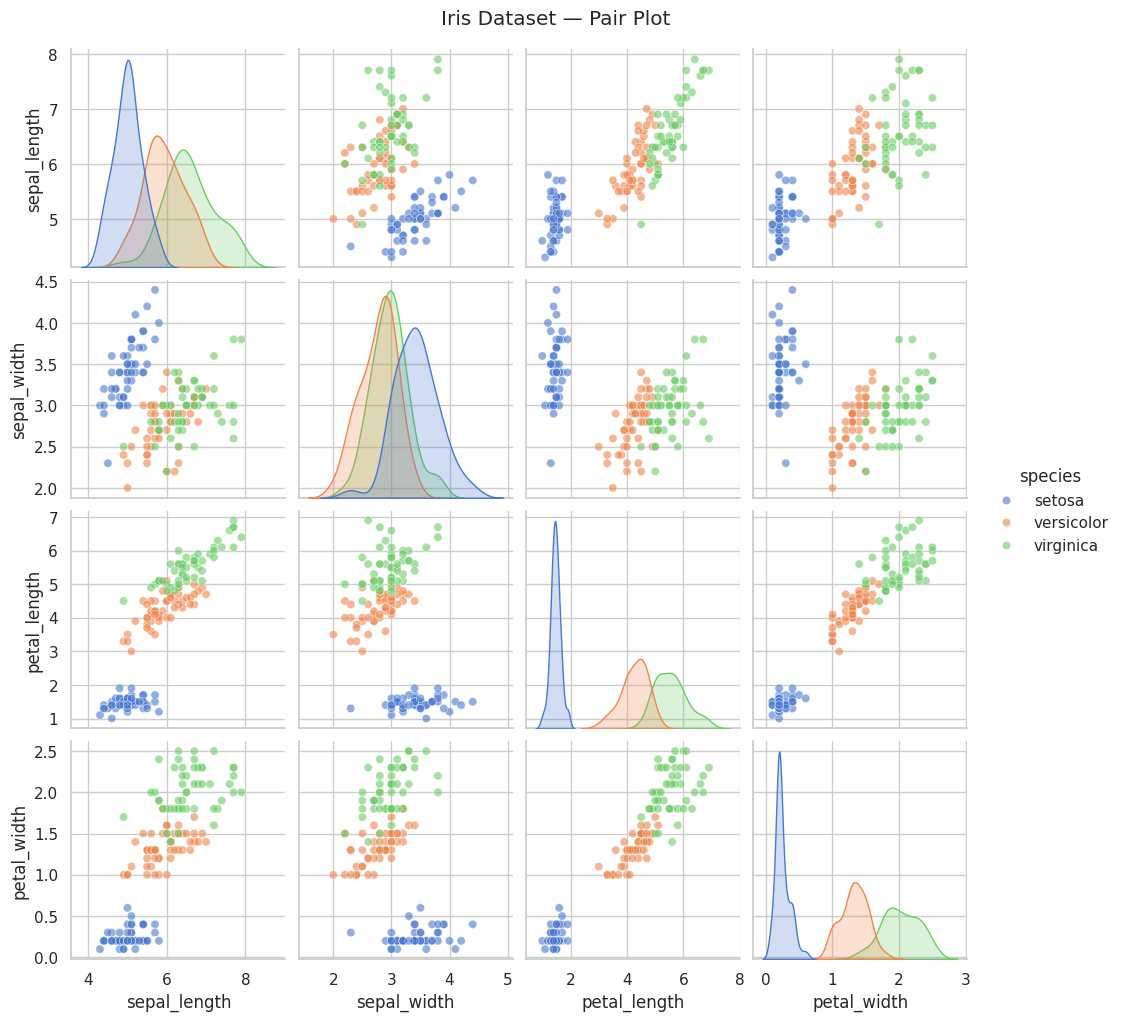

In [11]:
# pairplot — scatter matrix with KDE diagonal
g = sns.pairplot(iris, hue='species', diag_kind='kde',
                 plot_kws={'alpha': 0.6}, height=2.5)
g.figure.suptitle('Iris Dataset — Pair Plot', y=1.02)
plt.show()

## 6. Themes and Palettes

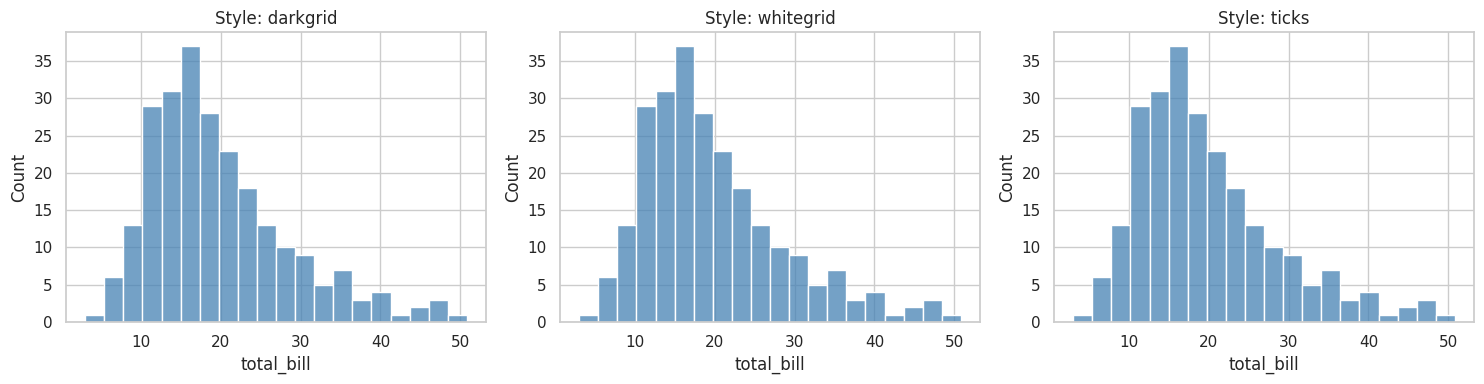

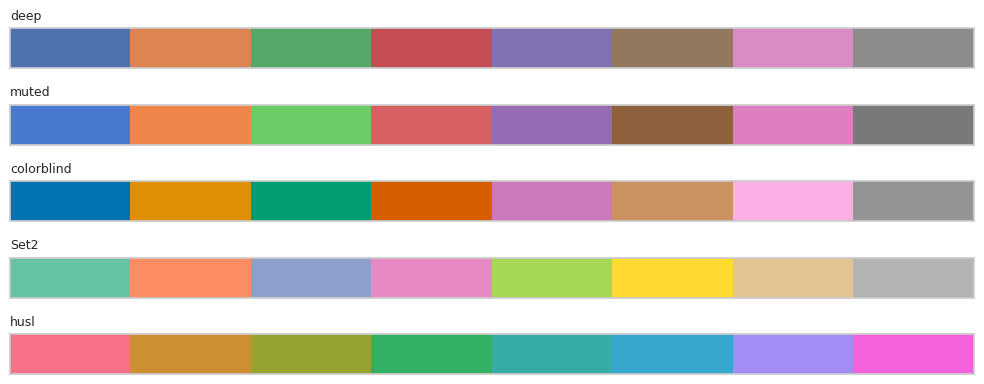

In [12]:
# Available themes: white, whitegrid, dark, darkgrid, ticks
# Available palettes: muted, pastel, deep, bright, dark, colorblind, Set2, husl

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
themes = ['darkgrid', 'whitegrid', 'ticks']

for ax, theme in zip(axes, themes):
    with sns.axes_style(theme):
        sns.histplot(tips['total_bill'], bins=20, ax=ax, color='steelblue')
        ax.set_title(f'Style: {theme}')

plt.tight_layout()
plt.show()

# Viewing colour palettes -- sns.palplot() always draws its own figure and takes no `ax`
# kwarg, so to place swatches on an existing multi-panel grid we draw them by hand with
# ax.imshow() instead.
palettes = ['deep', 'muted', 'colorblind', 'Set2', 'husl']
fig, axes = plt.subplots(len(palettes), 1, figsize=(10, len(palettes) * 0.8))
for ax, name in zip(axes, palettes):
    colors = sns.color_palette(name, 8)
    ax.imshow([colors], aspect='auto')
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_title(name, fontsize=9, loc='left')
plt.tight_layout()
plt.show()

## 7. From-Scratch — N/A (documented)

Seaborn *is* the higher-level convenience layer described in the Conceptual Foundation above —
there is no meaningfully "lower level" reimplementation to build here that isn't just the
Matplotlib topic's raw-`Rectangle` bar chart demo (`../05-matplotlib/matplotlib_basics.ipynb`,
section "3b"). That demo already shows exactly what a categorical Seaborn plot such as
`sns.barplot`/`sns.countplot` automates underneath: computing bar geometry and creating
`Rectangle` patches on a Matplotlib Axes. Re-deriving it again here would duplicate that
section rather than add insight — this topic's from-scratch section is a citation, not new
code, and that is a deliberate scope decision, not an omission.

## 8. Failure Modes — Aggregation Hides the Underlying Distribution

`sns.barplot`'s default aggregation (mean + confidence interval) can look perfectly
unremarkable while hiding a bimodal — or otherwise non-unimodal — underlying distribution,
because a mean is a single summary number that exists whether or not any real observation is
anywhere near it.

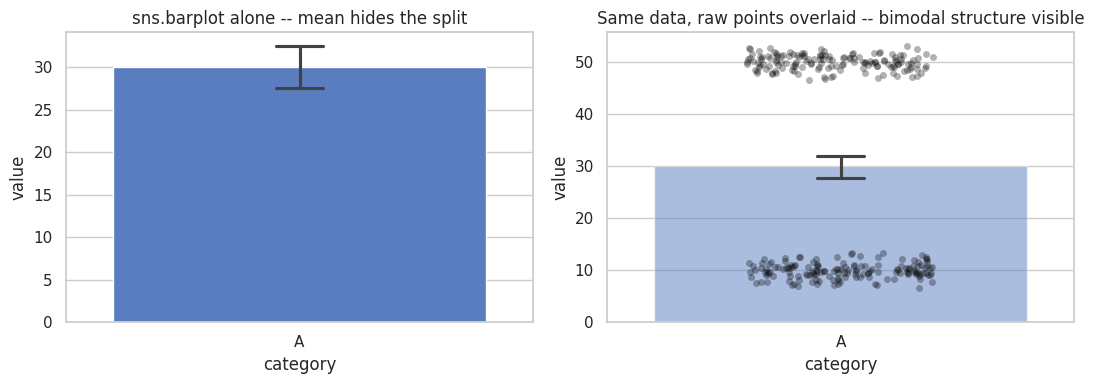

Mean of the aggregated bar: 29.97
That single mean (~30) does not correspond to any real observation --
every data point clusters near 10 or near 50, none near 30.


In [13]:
np.random.seed(7)
# Two underlying subpopulations for the SAME category -- e.g. two distinct customer segments
group_low  = np.random.normal(10, 1.5, 150)
group_high = np.random.normal(50, 1.5, 150)
bimodal = np.concatenate([group_low, group_high])
bimodal_df = pd.DataFrame({'category': ['A'] * len(bimodal), 'value': bimodal})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: barplot alone -- mean +/- CI looks like one smooth, unremarkable center
sns.barplot(data=bimodal_df, x='category', y='value', errorbar='ci', capsize=0.1, ax=axes[0])
axes[0].set_title('sns.barplot alone -- mean hides the split')

# Right: same barplot with raw points overlaid -- the bimodal split becomes visible
sns.barplot(data=bimodal_df, x='category', y='value', errorbar='ci', capsize=0.1,
            alpha=0.5, ax=axes[1])
sns.stripplot(data=bimodal_df, x='category', y='value', color='black', alpha=0.3,
              jitter=0.2, ax=axes[1])
axes[1].set_title('Same data, raw points overlaid -- bimodal structure visible')

plt.tight_layout()
plt.show()

print('Mean of the aggregated bar:', round(bimodal.mean(), 2))
print('That single mean (~30) does not correspond to any real observation --')
print('every data point clusters near 10 or near 50, none near 30.')

## Quick Summary

| Plot | Function | Use for |
|------|----------|---------|
| Histogram + KDE | `sns.histplot(kde=True)` | Single distribution |
| KDE | `sns.kdeplot()` | Smooth density, compare groups |
| Box | `sns.boxplot()` | Median, IQR, outliers by category |
| Violin | `sns.violinplot()` | Distribution shape + box |
| Strip | `sns.stripplot()` | Raw data points per category |
| Bar | `sns.barplot()` | Mean + CI per category |
| Count | `sns.countplot()` | Category frequencies |
| Scatter | `sns.scatterplot()` | Two continuous variables |
| Regression | `sns.regplot()` | Correlation + trend line |
| Heatmap | `sns.heatmap()` | Correlation matrix, pivots |
| Pair plot | `sns.pairplot()` | All-vs-all scatter matrix |

**Next →** [07 – SQLite](../07-sqlite/)